In [1]:
#1. Imports

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm

In [2]:
#2. Data Configuration
USE_DEMO = True

DATA_PATH         = "your_data.csv"
DATE_COL          = "date"
TARGET_COL        = "y"
INTERVENTION_DATE = "2024-06-01"  # YYYY-MM-DD

MAX_DONORS        = 5
CORR_THRESHOLD    = 0.6

SAVE_PLOT         = True
PLOT_PATH         = "causal_impact_results.png"

print("config set")

config set


In [3]:
#3. Helper functions

def load_csv(path, date_col, target_col):
    df = pd.read_csv(path, parse_dates=[date_col])
    df = df.sort_values(date_col).set_index(date_col)
    if target_col not in df.columns:
        raise ValueError(f"Column '{target_col}' not found. Available: {list(df.columns)}")
    cols = [target_col] + [c for c in df.columns if c != target_col]
    return df[cols].dropna(subset=[target_col])


def make_demo_data(n_pre=90, n_post=45, true_effect=15.0, seed=42):
    rng      = np.random.default_rng(seed)
    dates    = pd.date_range("2023-01-01", periods=n_pre + n_post, freq="W-MON")
    trend    = np.linspace(100, 130, n_pre + n_post)
    seasonal = 10 * np.sin(np.linspace(0, 4 * np.pi, n_pre + n_post))
    y        = trend + seasonal + rng.normal(0, 4, n_pre + n_post)
    y[n_pre:] += true_effect
    donor_1  = trend + seasonal + rng.normal(0, 5, n_pre + n_post) + 20
    donor_2  = 0.7 * trend + seasonal * 1.1 + rng.normal(0, 6, n_pre + n_post) - 10
    df       = pd.DataFrame({"y": y, "donor_1": donor_1, "donor_2": donor_2}, index=dates)
    df.index.name = "date"
    return df, dates[n_pre].strftime("%Y-%m-%d")


def select_donors(df, intervention_date, max_donors=5, corr_threshold=0.6):
    if df.shape[1] < 2:
        return []
    int_date   = pd.Timestamp(intervention_date)
    pre_df     = df[df.index < int_date]
    target_col = df.columns[0]
    scores     = {}
    for col in df.columns[1:]:
        pair = pre_df[[target_col, col]].dropna()
        if len(pair) < 10:
            continue
        r, _ = stats.pearsonr(pair[target_col], pair[col])
        if abs(r) >= corr_threshold:
            scores[col] = abs(r)
    return sorted(scores, key=scores.get, reverse=True)[:max_donors]


def fit_model(df, diag, donors):
    int_date   = diag["intervention_date"]
    target_col = df.columns[0]
    pre_df     = df[df.index < int_date]
    post_df    = df[df.index >= int_date]
    pre_y      = pre_df[target_col]
    post_y     = post_df[target_col]
    n_post     = len(post_df)

    pre_exog   = pre_df[donors].values  if donors else None
    post_exog  = post_df[donors].values if donors else None

    model = sm.tsa.UnobservedComponents(
        pre_y, level="local linear trend", exog=pre_exog
    )
    res = model.fit(disp=False, method="lbfgs")

    forecast   = res.get_forecast(steps=n_post, exog=post_exog)
    cf_mean    = forecast.predicted_mean.values
    cf_ci      = forecast.conf_int(alpha=0.05)
    cf_lower   = cf_ci.iloc[:, 0].values
    cf_upper   = cf_ci.iloc[:, 1].values

    actual     = post_y.values
    abs_effect = actual - cf_mean
    cum_effect = np.cumsum(abs_effect)

    effect_se    = (cf_upper - cf_lower) / (2 * norm.ppf(0.975))
    effect_lower = abs_effect - 1.96 * effect_se
    effect_upper = abs_effect + 1.96 * effect_se

    cum_se     = np.sqrt(np.cumsum(effect_se ** 2))
    cum_lower  = cum_effect - 1.96 * cum_se
    cum_upper  = cum_effect + 1.96 * cum_se

    avg_se     = effect_se.mean()
    z          = abs_effect.mean() / avg_se if avg_se > 0 else 0
    p_value    = min(norm.cdf(z), 1 - norm.cdf(z)) * 2

    return {
        "index"                  : post_df.index,
        "full_index"             : df.index,
        "actual_full"            : df[target_col].values,
        "cf_full"                : np.concatenate([pre_y.values, cf_mean]),
        "cf_lower_full"          : np.concatenate([pre_y.values, cf_lower]),
        "cf_upper_full"          : np.concatenate([pre_y.values, cf_upper]),
        "actual_post"            : actual,
        "cf_mean"                : cf_mean,
        "cf_lower"               : cf_lower,
        "cf_upper"               : cf_upper,
        "abs_effect"             : abs_effect,
        "effect_lower"           : effect_lower,
        "effect_upper"           : effect_upper,
        "cum_effect"             : cum_effect,
        "cum_lower"              : cum_lower,
        "cum_upper"              : cum_upper,
        "p_value"                : p_value,
        "significant"            : p_value < 0.05,
        "pre_mean"               : diag["pre_mean"],
        "predicted_mean"         : cf_mean.mean(),
        "actual_mean"            : actual.mean(),
        "abs_effect_mean"        : abs_effect.mean(),
        "abs_effect_lower"       : effect_lower.mean(),
        "abs_effect_upper"       : effect_upper.mean(),
        "rel_effect_pct"         : (abs_effect.mean() / cf_mean.mean()) * 100,
        "cumulative_effect"      : cum_effect[-1],
        "cumulative_effect_lower": cum_lower[-1],
        "cumulative_effect_upper": cum_upper[-1],
    }


In [9]:
if USE_DEMO:
    df, INTERVENTION_DATE = make_demo_data()
    print(f"✓ synthetic dataset ready — {len(df)} rows")
    print(f"  Intervention date : {INTERVENTION_DATE}  (true effect = +15 units/week)")
else:
    df = load_csv(DATA_PATH, DATE_COL, TARGET_COL)
    print(f"✓ loaded '{DATA_PATH}' — {len(df)} rows, {df.shape[1]} columns")

df.head()

✓ synthetic dataset ready — 135 rows
  Intervention date : 2024-09-23  (true effect = +15 units/week)


,y,donor_1,donor_2
date,,,
2023-01-02,101.218868,114.922105,55.670652
2023-01-09,97.000359,122.727865,63.085738
2023-01-16,105.314167,126.502995,61.780774
2023-01-23,107.210301,133.431696,76.083199
2023-01-30,96.755182,139.128635,74.097176


In [10]:
target   = df.iloc[:, 0]
int_date = pd.Timestamp(INTERVENTION_DATE)
if int_date not in df.index:
    int_date = df.index[df.index.searchsorted(int_date)]

pre  = target[target.index < int_date]
post = target[target.index >= int_date]
adf_stat, adf_p, *_ = adfuller(pre.dropna(), autolag="AIC")

diag = {
    "intervention_date": int_date,
    "n_pre"            : len(pre),
    "n_post"           : len(post),
    "n_covariates"     : df.shape[1] - 1,
    "pre_mean"         : pre.mean(),
    "pre_std"          : pre.std(),
    "adf_statistic"    : adf_stat,
    "adf_p_value"      : adf_p,
    "is_stationary"    : adf_p < 0.05,
}

print(f"  Intervention date : {diag['intervention_date'].date()}")
print(f"  Pre-period        : {diag['n_pre']} observations  (mean = {diag['pre_mean']:.2f})")
print(f"  Post-period       : {diag['n_post']} observations")
print(f"  Covariates        : {diag['n_covariates']}")
print(f"  ADF stationarity  : p = {diag['adf_p_value']:.4f}  ({'stationary' if diag['is_stationary'] else 'non-stationary — UCM handles this fine'})")

if diag["n_pre"] < 20:
    raise ValueError(f"Need ≥20 pre-period observations, got {diag['n_pre']}.")


  Intervention date : 2024-09-23
  Pre-period        : 90 observations  (mean = 111.79)
  Post-period       : 45 observations
  Covariates        : 2
  ADF stationarity  : p = 0.7328  (non-stationary — UCM handles this fine)


In [11]:
donors = select_donors(df, INTERVENTION_DATE, MAX_DONORS, CORR_THRESHOLD)

if donors:
    int_date_ts = pd.Timestamp(INTERVENTION_DATE)
    pre_df = df[df.index < int_date_ts]
    target_col = df.columns[0]
    print(f"  Donors selected ({len(donors)}):")
    for d in donors:
        r, _ = stats.pearsonr(pre_df[target_col].dropna(), pre_df[d].dropna())
        print(f"    {d:<20}  pre-period r = {r:+.3f}")
else:
    print("  No donors met the correlation threshold — running univariate model.")

  Donors selected (2):
    donor_1               pre-period r = +0.815
    donor_2               pre-period r = +0.719


In [12]:
print("Fitting UCM (local linear trend) ... this may take a few seconds")
results = fit_model(df, diag, donors)

print(f"  Counterfactual mean : {results['predicted_mean']:.4f}")
print(f"  Actual mean         : {results['actual_mean']:.4f}")
print(f"  Avg absolute effect : {results['abs_effect_mean']:+.4f}")
sep = "─" * 52
sig = "Yes" if results["significant"] else "No"

print(f"\n{sep}")
print("  CAUSAL IMPACT REPORT")
print(sep)
print(f"  Intervention date   : {diag['intervention_date'].date()}")
print(f"  Pre / post obs      : {diag['n_pre']} / {diag['n_post']}")
print(f"  Donors used         : {diag['n_covariates']}")
print(f"  Pre-period mean     : {results['pre_mean']:.4f}")
print(sep)
print(f"  Counterfactual mean : {results['predicted_mean']:.4f}")
print(f"  Actual mean         : {results['actual_mean']:.4f}")
print(f"  Avg absolute effect : {results['abs_effect_mean']:.4f}"
      f"  [{results['abs_effect_lower']:.4f}, {results['abs_effect_upper']:.4f}]")
print(f"  Relative effect     : {results['rel_effect_pct']:+.2f}%")
print(f"  Cumulative effect   : {results['cumulative_effect']:.4f}"
      f"  [{results['cumulative_effect_lower']:.4f}, {results['cumulative_effect_upper']:.4f}]")
print(sep)
print(f"  p-value             : {results['p_value']:.4f}")
print(f"  Statistically sig.  : {sig}  (α = 0.05)")
print(sep)

Fitting UCM (local linear trend) ... this may take a few seconds
  Counterfactual mean : 140.3710
  Actual mean         : 135.5734
  Avg absolute effect : -4.7976

────────────────────────────────────────────────────
  CAUSAL IMPACT REPORT
────────────────────────────────────────────────────
  Intervention date   : 2024-09-23
  Pre / post obs      : 90 / 45
  Donors used         : 2
  Pre-period mean     : 111.7939
────────────────────────────────────────────────────
  Counterfactual mean : 140.3710
  Actual mean         : 135.5734
  Avg absolute effect : -4.7976  [-44.9166, 35.3213]
  Relative effect     : -3.42%
  Cumulative effect   : -215.8933  [-530.6276, 98.8411]
────────────────────────────────────────────────────
  p-value             : 0.8147
  Statistically sig.  : No  (α = 0.05)
────────────────────────────────────────────────────


/tmp/ipykernel_287/1049029509.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [saved] causal_impact_results.png


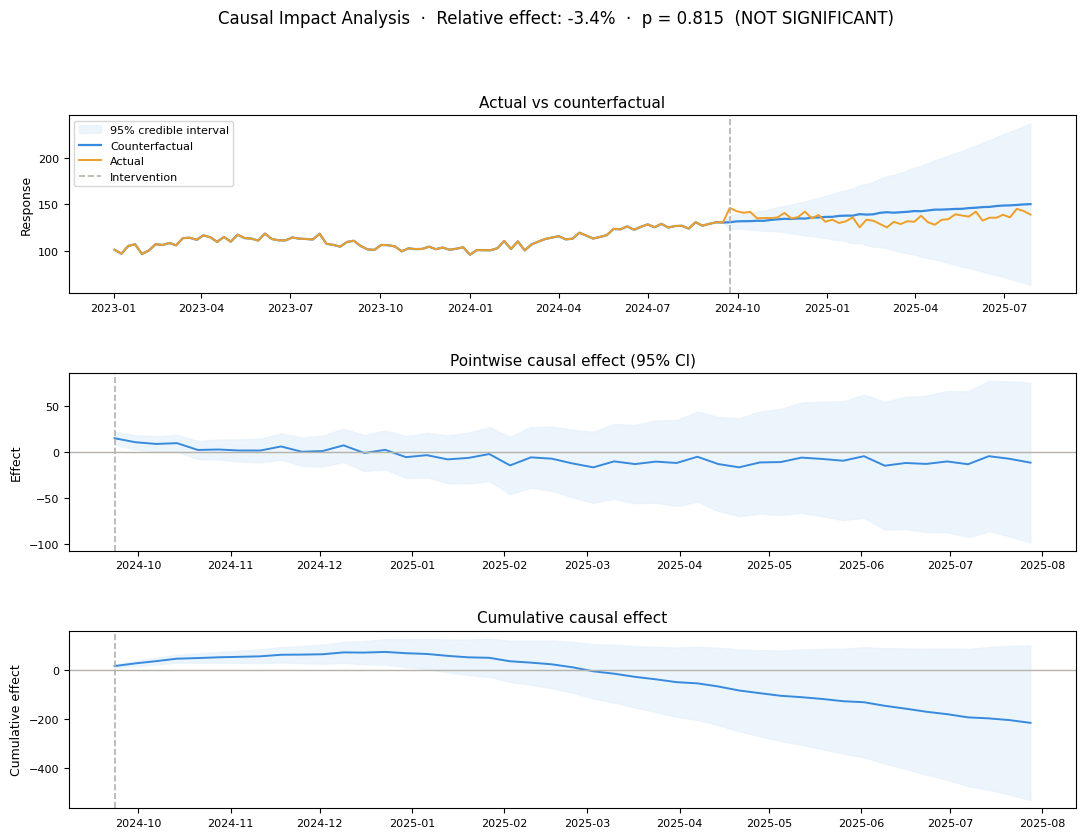

In [13]:
int_date = diag["intervention_date"]
blue, orange, gray, band = "#378ADD", "#EF9F27", "#B4B2A9", "#E6F1FB"

fig = plt.figure(figsize=(13, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# Panel 1 – actual vs counterfactual
ax1 = fig.add_subplot(gs[0])
ax1.fill_between(results["full_index"], results["cf_lower_full"], results["cf_upper_full"],
                 color=band, alpha=0.7, label="95% credible interval")
ax1.plot(results["full_index"], results["cf_full"], color=blue, lw=1.6, label="Counterfactual")
ax1.plot(results["full_index"], results["actual_full"], color=orange, lw=1.4, label="Actual")
ax1.axvline(int_date, color=gray, lw=1.2, ls="--", label="Intervention")
ax1.set_title("Actual vs counterfactual", fontsize=11, pad=6)
ax1.legend(fontsize=8, loc="upper left")
ax1.set_ylabel("Response", fontsize=9)
ax1.tick_params(labelsize=8)

# Panel 2 – pointwise effect
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(results["index"], results["effect_lower"], results["effect_upper"],
                 color=band, alpha=0.7)
ax2.plot(results["index"], results["abs_effect"], color=blue, lw=1.4)
ax2.axhline(0, color=gray, lw=1)
ax2.axvline(int_date, color=gray, lw=1.2, ls="--")
ax2.set_title("Pointwise causal effect (95% CI)", fontsize=11, pad=6)
ax2.set_ylabel("Effect", fontsize=9)
ax2.tick_params(labelsize=8)

# Panel 3 – cumulative effect
ax3 = fig.add_subplot(gs[2])
ax3.fill_between(results["index"], results["cum_lower"], results["cum_upper"],
                 color=band, alpha=0.7)
ax3.plot(results["index"], results["cum_effect"], color=blue, lw=1.4)
ax3.axhline(0, color=gray, lw=1)
ax3.axvline(int_date, color=gray, lw=1.2, ls="--")
ax3.set_title("Cumulative causal effect", fontsize=11, pad=6)
ax3.set_ylabel("Cumulative effect", fontsize=9)
ax3.tick_params(labelsize=8)

sig_label = "SIGNIFICANT" if results["significant"] else "NOT SIGNIFICANT"
fig.suptitle(
    f"Causal Impact Analysis  ·  Relative effect: {results['rel_effect_pct']:+.1f}%"
    f"  ·  p = {results['p_value']:.3f}  ({sig_label})",
    fontsize=12, y=0.998
)
plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
    print(f"  [saved] {PLOT_PATH}")
plt.show()